## Data preparation & Data split

### Load the admission data

- the inflow/outflow direcly derived from `icu_patients(re-assign).csv`.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [17]:
def load_data(fpath, assigned: bool = False) -> pd.DataFrame:
    """Load ICU patient dynamics data from icu_patients file"""
    if assigned:
        df = pd.read_csv(fpath)[["assigned_intime", "assigned_outtime", "first_careunit"]]
        df.rename(columns={
            "assigned_intime": "intime",
            "assigned_outtime": "outtime"
        }, inplace=True)
    else:
        df = pd.read_csv(fpath)[["intime", "outtime", "first_careunit"]]
    
    df["intime"] = pd.to_datetime(df["intime"]).dt.date
    df["outtime"] = pd.to_datetime(df["outtime"]).dt.date

    # Calculate daily inflow, outflow, and occupancy
    inflow = df.groupby('intime').size().rename('inflow')
    outflow = df.groupby('outtime').size().rename('outflow')
    dynamics = pd.concat([inflow, outflow], axis=1).fillna(0).reset_index().rename(columns={'index': 'date'})

    dynamics.sort_values('date', inplace=True)
    dynamics.reset_index(drop=True, inplace=True)

    dynamics["date"] = pd.to_datetime(dynamics["date"])
    dynamics["inflow"] = dynamics["inflow"].astype(int)
    dynamics["outflow"] = dynamics["outflow"].astype(int)

    dynamics["occupancy"] = dynamics["inflow"].cumsum() - dynamics["outflow"].cumsum()

    return dynamics

fpath = 'Merged_Dataset/icu_patients(re-assign).csv'

# here we load the assigned date
df = load_data(fpath, assigned=True)
df.to_csv('Merged_Dataset/dynamics(assigned).csv', index=False)

(array([ 71.,  67.,  80.,  51., 137.,  72., 118., 131., 429., 260., 333.,
        337., 856., 427., 377., 379., 371., 576., 230., 163., 118., 130.,
         39.,  38.,  18.,  26.,   3.,   3.,   2.,   1.]),
 array([ 0.        ,  1.23333333,  2.46666667,  3.7       ,  4.93333333,
         6.16666667,  7.4       ,  8.63333333,  9.86666667, 11.1       ,
        12.33333333, 13.56666667, 14.8       , 16.03333333, 17.26666667,
        18.5       , 19.73333333, 20.96666667, 22.2       , 23.43333333,
        24.66666667, 25.9       , 27.13333333, 28.36666667, 29.6       ,
        30.83333333, 32.06666667, 33.3       , 34.53333333, 35.76666667,
        37.        ]),
 <BarContainer object of 30 artists>)

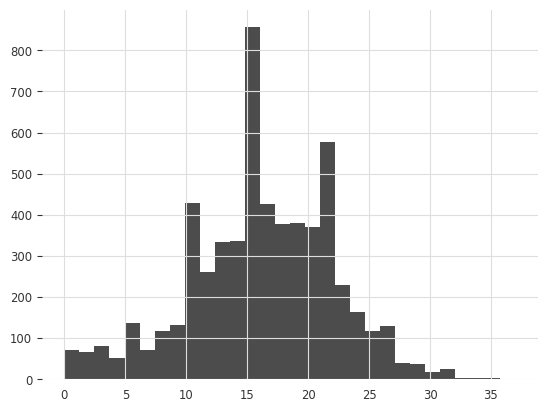

In [19]:
plt.hist(df['inflow'], bins=30, alpha=0.7, color='black', label='Inflow')

<Axes: title={'center': 'ICU Daily Admission Over Time'}, xlabel='Date', ylabel='Inflow'>

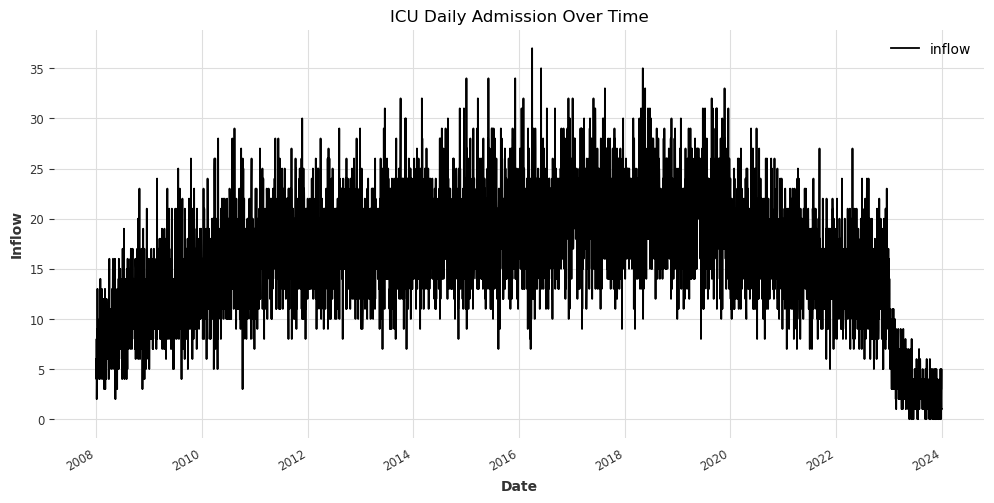

In [20]:
df.plot(x='date', y='inflow', title='ICU Daily Admission Over Time', ylabel='Inflow', xlabel='Date', figsize=(12,6), color='black')

In [21]:
df[df["date"].dt.year < 2023]["inflow"].mean(), df[df["date"].dt.year == 2023]["inflow"].mean()

(17.002190180689908, 3.57967032967033)

### Data Split

If want to train and test the data only before 2023, run the line below.

In [22]:
# df = df[df['date'].dt.year < 2023]

In [23]:
from darts import TimeSeries

series = TimeSeries.from_dataframe(
    df,
    time_col='date',
    value_cols='inflow',
    freq='D',
    fill_missing_dates=True, # ensure the dates are continuous
    fillna_value= 0 # fill missing values with 0
)

print(f"Series length: {len(series)}")
print(f"Date range: {series.start_time()} to {series.end_time()}")

Series length: 5844
Date range: 2008-01-01 00:00:00 to 2023-12-31 00:00:00


In [24]:
train, test = series.split_after(split_point=pd.to_datetime("2020-05-18"))

print(f"Train: {len(train)} days, from {train.start_time()} to {train.end_time()}")
print(f"Test: {len(test)} days, from {test.start_time()} to {test.end_time()}")

Train: 4522 days, from 2008-01-01 00:00:00 to 2020-05-18 00:00:00
Test: 1322 days, from 2020-05-19 00:00:00 to 2023-12-31 00:00:00


### STL decomposition for seasonality and trend strength


STL DECOMPOSITION (Seasonal-Trend decomposition using LOESS)


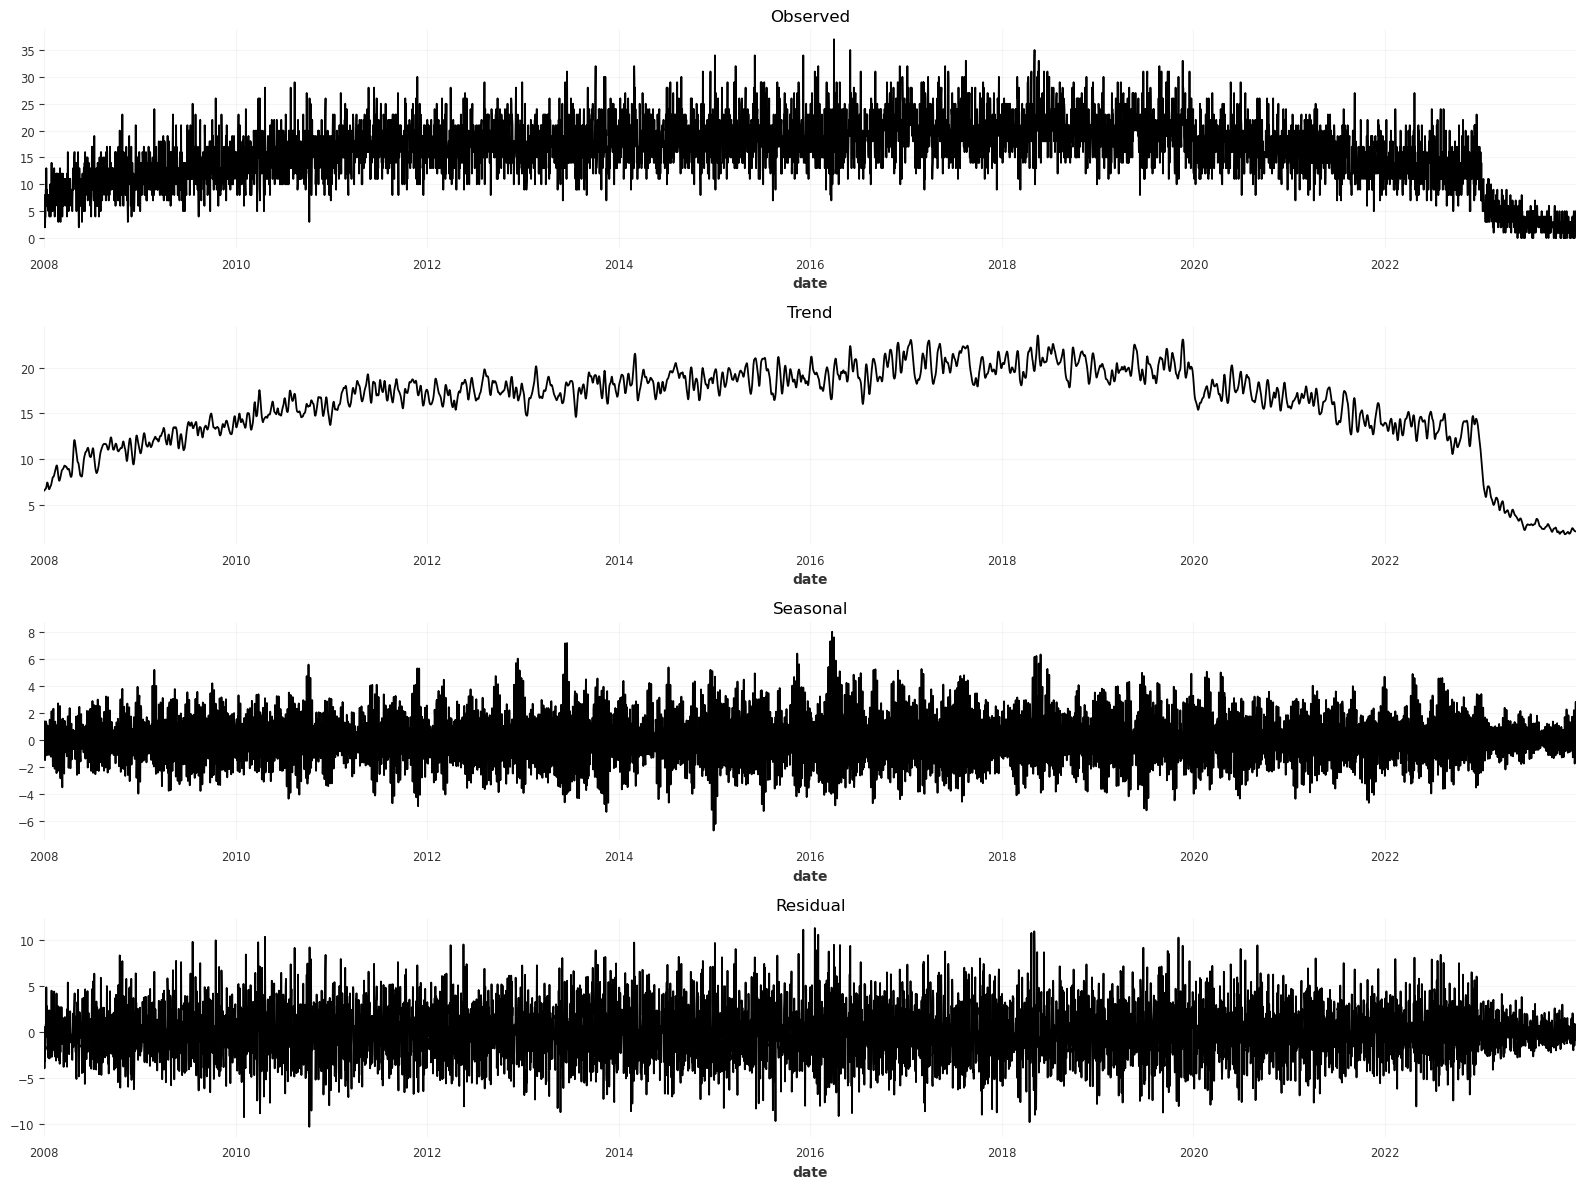


Component Statistics:
Trend strength: 0.688
Seasonal strength: 0.338


In [26]:
from statsmodels.tsa.seasonal import STL
ts_data = df.set_index('date')['inflow']
ts_data = ts_data.resample('D').sum()

print("\n" + "="*60)
print("STL DECOMPOSITION (Seasonal-Trend decomposition using LOESS)")
print("="*60)

# STL is more robust to outliers
stl = STL(ts_data, seasonal=7, trend=21)  # Weekly seasonal, 3-week trend
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

result.observed.plot(ax=axes[0], title='Observed')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze components
print("\nComponent Statistics:")
print(f"Trend strength: {1 - np.var(result.resid) / np.var(result.trend + result.resid):.3f}")
print(f"Seasonal strength: {1 - np.var(result.resid) / np.var(result.seasonal + result.resid):.3f}")

## Modelling

**Dependencies**:
- python=3.11
- darts==0.38.0
- statsforecast==2.0.2

**Target**: at time point $t_n$, predict the total admissions over the next $d$ days

**Pipeline**:
- Split data chronologically into trainset/testset (as shown in `Data Split` in last section).
- Train the model on the trainset
- **Ideas to generate forecasts: use trained models to obtain forecasts from $t_{n+1}$ and $t_{n+d}$, then sum them up (i.e. `aggregation` defined below)**
- Evaluate the aggregated predictions using MAE, RMSE, MAPE (by rolling-origin CV)
- Visualisation & Residual Analysis

Aggregation method to sum up the predicted admissions over next $d$ days.

In [27]:
def aggregation(true_series, pred_series):
    '''
    :param true_series: predicted values generated from historical_forecasts (not aggregated)
    :param pred_series: true values from the original series (not aggregated either)
    '''
    agg_pred = [[p.values().sum()] for p in pred_series]
    agg_true = [[true_series.slice(p.start_time(), p.end_time()).values().sum()] for p in pred_series]
    time_index = pd.DatetimeIndex([p.start_time() for p in pred_series])
    agg_pred = TimeSeries.from_times_and_values(time_index, np.array(agg_pred))
    agg_true = TimeSeries.from_times_and_values(time_index, np.array(agg_true))

    return agg_true, agg_pred

Evaluation method used for generating the evaluation metircs.

In [28]:
def evaluation(preds, truevals):
    '''
    :param preds: predicted TimeSeries
    :param truevals: true TimeSeries
    '''
    from darts.metrics import mae, mape, rmse
    from statsmodels.stats.diagnostic import acorr_ljungbox

    mae_val = mae(truevals, preds)
    rmse_val = rmse(truevals, preds)
    try:
        mape_val = mape(truevals, preds)
    except:
        mape_val = np.inf

    residuals = truevals.values().flatten() - preds.values().flatten()
    lb_pvalue = acorr_ljungbox(residuals, lags=[10], return_df=True)["lb_pvalue"].iloc[0]

    return {'MAE': mae_val, 'RMSE': rmse_val, 'MAPE': mape_val, "lb_pvalue": lb_pvalue}

Import necessary libraries and models.

In [29]:
import numpy as np
from darts.models import (
    NaiveMean,
    ExponentialSmoothing,
    ARIMA,
    Prophet,
    RandomForestModel,
    AutoARIMA,
    NaiveMovingAverage, NaiveSeasonal
)

from darts.metrics import mape, rmse, mae
# from darts.metrics import rmsse, mase

from darts.dataprocessing.transformers import Scaler
from statsmodels.stats.diagnostic import acorr_ljungbox

### Single-point, Aggregated, Strided predictions (forecast horizon = d)

The horizon can be adjusted by changing the value of `d` in the following line.

In [30]:
d=7  # forecast horizon

The function used to train and evaluation.

In [ ]:
def train_test_evaluation(train, test, model, d=7, stride=1, 
    scaled=False, retrain=True):
    '''
    :param train: training TimeSeries
    :param test: testing TimeSeries
    :param model: Darts forecasting model
    :param d: forecast horizon (days)
    :param stride: rolling-origin stride
    :param scaled: whether to scale the data (for machine learning models)
    '''
    
    full_series = train.concatenate(test)

    try:
        print(f"---------- Training the model : {model} ----------")
        # Train the model
        if scaled:
            scaler = Scaler()
            train_scaled = scaler.fit_transform(train)
            model.fit(train_scaled)
        else:
            model.fit(train)

        # Generate forecasts on test set 
        # Each forecasts across d days (e.g. 1st one is from 2020-01-01 to 2020-01-07)
        test_preds = model.historical_forecasts(
            series=full_series,
            start=len(train),          # starting index of first point in test set
            forecast_horizon=d,        # predict d days ahead
            stride=stride,             # rolling-origin stride
            retrain=retrain,           # whether to retrain at every starting point
            last_points_only=False,    # get all d-days forecasts
            verbose=True
        )
        print("The test results are from ", test.start_time(), "to", test.end_time(), " with length", len(test), "days.")
        print("The first prediction results are from ", test_preds[0].start_time(), "to", test_preds[0].end_time())
        print("The last prediction results are from ", test_preds[-1].start_time(), "to", test_preds[-1].end_time())
        print("Number of prediction series: ", len(test_preds))


        # single-point forecasts
        single_point_preds = list(map(lambda x: x[-1:].values().flatten(), test_preds))
        time_index = pd.DatetimeIndex([p.end_time() for p in test_preds])
        single_point_preds = TimeSeries.from_times_and_values(time_index, np.array(single_point_preds).flatten())
        if scaled:
            single_point_preds = scaler.inverse_transform(single_point_preds)
        single_true = test.slice(test_preds[0].end_time(), test_preds[-1].end_time())
        single_point_metrics = evaluation(single_point_preds, single_true)

        # aggregated forecasts
        agg_test, agg_test_preds = aggregation(test, test_preds)
        if scaled:
            agg_test_preds = scaler.inverse_transform(agg_test_preds)
        agg_metrics = evaluation(agg_test_preds, agg_test)
        
        # strided aggregated forecasts
        agg_test_strided = agg_test[::d]
        agg_test_preds_strided = agg_test_preds[::d]
        strided_agg_metrics = evaluation(agg_test_preds_strided, agg_test_strided)

        return single_point_metrics, agg_metrics, strided_agg_metrics, model
    
    except Exception as e:
        print(f"\t Error: {str(e)}")
        return {}, {} , None

In [ ]:
# baseline models to evaluate
baseline_models = {
    'NaiveMean': NaiveMean(),
    # 'Moving Average (7 days)': NaiveMovingAverage(input_chunk_length=7),
    'Moving Average (30 days)': NaiveMovingAverage(input_chunk_length=30),
    #'Seasonal Naive (7 days)': NaiveSeasonal(K=7),
    'AutoARIMA': AutoARIMA(),
    # 'Prophet': Prophet()
}

single_test_results = {}
agg_test_results = {}
strided_agg_results = {}
trained_models = {}

In [33]:
for model_name, model in baseline_models.items():
    print(f"Evaluating model: {model_name}")

    if model_name in ["AutoARIMA"]:
        retrain = False
    else:
        retrain = True

    single_point_metrics, agg_metrics, strided_agg_metrics, trained_model = train_test_evaluation(
        train, test, model,
        d=d,
        stride=1,
        no_aggregation=True, # keep only the d-day forecasts
        scaled=False,
        retrain=retrain
    )

    single_test_results[model_name] = single_point_metrics
    agg_test_results[model_name] = agg_metrics
    strided_agg_results[model_name] = strided_agg_metrics
    trained_models[model_name] = trained_model

    print("\nEvaluation results of single point prediction:")
    for metric, value in single_point_metrics.items():
        print(f"  {metric}: {value:.4f}")

    print("\nEvaluation results of aggregated prediction:")
    for metric, value in agg_metrics.items():
        print(f"  {metric}: {value:.4f}")
    print("\n" +  "-"*40 + "\n")



Evaluating model: NaiveMean
---------- Training the model : NaiveMean() ----------


historical forecasts:   0%|          | 0/1316 [00:00<?, ?it/s]

ValueError: `actual_series` must be strictly positive to compute the MAPE.


The test results are from  2020-05-19 00:00:00 to 2023-12-31 00:00:00  with length 1322 days.
The first prediction results are from  2020-05-19 00:00:00 to 2020-05-25 00:00:00
The last prediction results are from  2023-12-25 00:00:00 to 2023-12-31 00:00:00
Number of prediction series:  1316

Evaluation results of single point prediction:
  MAE: 6.3749
  RMSE: 8.0094
  MAPE: inf
  lb_pvalue: 0.0000

Evaluation results of aggregated prediction:
  MAE: 37.8296
  RMSE: 51.4567
  MAPE: 139.6593
  lb_pvalue: 0.0000

----------------------------------------

Evaluating model: Moving Average (30 days)
---------- Training the model : NaiveMovingAverage(30) ----------


historical forecasts:   0%|          | 0/1316 [00:00<?, ?it/s]

ValueError: `actual_series` must be strictly positive to compute the MAPE.


The test results are from  2020-05-19 00:00:00 to 2023-12-31 00:00:00  with length 1322 days.
The first prediction results are from  2020-05-19 00:00:00 to 2020-05-25 00:00:00
The last prediction results are from  2023-12-25 00:00:00 to 2023-12-31 00:00:00
Number of prediction series:  1316

Evaluation results of single point prediction:
  MAE: 2.7444
  RMSE: 3.5294
  MAPE: inf
  lb_pvalue: 0.0000

Evaluation results of aggregated prediction:
  MAE: 8.7246
  RMSE: 11.3953
  MAPE: 12.8417
  lb_pvalue: 0.0000

----------------------------------------

Evaluating model: AutoARIMA
---------- Training the model : AutoARIMA() ----------


historical forecasts:   0%|          | 0/1316 [00:00<?, ?it/s]

ValueError: `actual_series` must be strictly positive to compute the MAPE.


The test results are from  2020-05-19 00:00:00 to 2023-12-31 00:00:00  with length 1322 days.
The first prediction results are from  2020-05-19 00:00:00 to 2020-05-25 00:00:00
The last prediction results are from  2023-12-25 00:00:00 to 2023-12-31 00:00:00
Number of prediction series:  1316

Evaluation results of single point prediction:
  MAE: 2.9548
  RMSE: 3.6914
  MAPE: inf
  lb_pvalue: 0.0000

Evaluation results of aggregated prediction:
  MAE: 10.7533
  RMSE: 13.7069
  MAPE: 22.1561
  lb_pvalue: 0.0000

----------------------------------------



In [ ]:
from darts.utils.utils import ModelMode, SeasonalityMode
# ES models used to be evaluated
ES_models = {
    'Holt-Winters Seasonal': ExponentialSmoothing(trend=ModelMode.ADDITIVE, seasonal=SeasonalityMode.ADDITIVE, random_state=5188),
    'Holt linear Trend': ExponentialSmoothing( trend=ModelMode.ADDITIVE, seasonal=None, random_state=5188)
}

for model_name, model in ES_models.items():
    print(f"Evaluating model: {model_name}")

    if model_name in ["AutoARIMA"]:
        retrain = False
    else:
        retrain = True

    single_point_metrics, agg_metrics, strided_agg_metrics, trained_model = train_test_evaluation(
        train, test, model,
        d=d,
        stride=1,
        no_aggregation=True, # keep only the d-day forecasts
        scaled=False,
        retrain=retrain
    )

    single_test_results[model_name] = single_point_metrics
    agg_test_results[model_name] = agg_metrics
    strided_agg_results[model_name] = strided_agg_metrics
    trained_models[model_name] = trained_model

    print("\nEvaluation results of single point prediction:")
    for metric, value in single_point_metrics.items():
        print(f"  {metric}: {value:.4f}")

    print("\nEvaluation results of aggregated prediction:")
    for metric, value in agg_metrics.items():
        print(f"  {metric}: {value:.4f}")
    print("\n" +  "="*40 + "\n")


Evaluating model: Holt-Winters Seasonal
---------- Training the model : ExponentialSmoothing(random_state=5188) ----------


historical forecasts:   0%|          | 0/1316 [00:00<?, ?it/s]

ValueError: `actual_series` must be strictly positive to compute the MAPE.


The test results are from  2020-05-19 00:00:00 to 2023-12-31 00:00:00  with length 1322 days.
The first prediction results are from  2020-05-19 00:00:00 to 2020-05-25 00:00:00
The last prediction results are from  2023-12-25 00:00:00 to 2023-12-31 00:00:00
Number of prediction series:  1316

Evaluation results of single point prediction:
  MAE: 2.7836
  RMSE: 3.5581
  MAPE: inf
  lb_pvalue: 0.0000

Evaluation results of aggregated prediction:
  MAE: 9.1316
  RMSE: 12.0074
  MAPE: 15.1752
  lb_pvalue: 0.0000


Evaluating model: Holt linear Trend
---------- Training the model : ExponentialSmoothing(seasonal=None, random_state=5188) ----------


historical forecasts:   0%|          | 0/1316 [00:00<?, ?it/s]

ValueError: `actual_series` must be strictly positive to compute the MAPE.


The test results are from  2020-05-19 00:00:00 to 2023-12-31 00:00:00  with length 1322 days.
The first prediction results are from  2020-05-19 00:00:00 to 2020-05-25 00:00:00
The last prediction results are from  2023-12-25 00:00:00 to 2023-12-31 00:00:00
Number of prediction series:  1316

Evaluation results of single point prediction:
  MAE: 2.7855
  RMSE: 3.5612
  MAPE: inf
  lb_pvalue: 0.0000

Evaluation results of aggregated prediction:
  MAE: 9.1377
  RMSE: 12.0322
  MAPE: 15.1010
  lb_pvalue: 0.0000




### Metrics of all models
- single-point
- aggregated: the total admissions over next $d$ days
- strided: the total admissions with non-overlapping forecast windows

In [37]:
single_test_results_df = pd.DataFrame.from_dict(single_test_results, orient='index')
single_test_results_df = single_test_results_df.reset_index().rename(columns={'index': 'Model'})
single_test_results_df = single_test_results_df.sort_values(by='MAE')
print("Single Point Test Results Summary:")
print(single_test_results_df)

Single Point Test Results Summary:
                      Model       MAE      RMSE  MAPE     lb_pvalue
1  Moving Average (30 days)  2.744440  3.529395   inf  6.885140e-08
3     Holt-Winters Seasonal  2.783612  3.558060   inf  3.895805e-21
4         Holt linear Trend  2.785489  3.561230   inf  2.782755e-21
2                 AutoARIMA  2.954835  3.691431   inf  4.750092e-25
0                 NaiveMean  6.374889  8.009355   inf  0.000000e+00


In [38]:
agg_test_results_df = pd.DataFrame.from_dict(agg_test_results, orient='index')
agg_test_results_df = agg_test_results_df.reset_index().rename(columns={'index': 'Model'})
agg_test_results_df = agg_test_results_df.sort_values(by='MAE')
print("Aggregated Test Results Summary:")
print(agg_test_results_df)

Aggregated Test Results Summary:
                      Model        MAE       RMSE        MAPE  lb_pvalue
1  Moving Average (30 days)   8.724619  11.395292   12.841654        0.0
3     Holt-Winters Seasonal   9.131607  12.007377   15.175227        0.0
4         Holt linear Trend   9.137662  12.032208   15.100962        0.0
2                 AutoARIMA  10.753313  13.706902   22.156062        0.0
0                 NaiveMean  37.829566  51.456728  139.659271        0.0


In [39]:
strided_agg_results_df = pd.DataFrame.from_dict(strided_agg_results, orient='index')
strided_agg_results_df = strided_agg_results_df.reset_index().rename(columns={'index': 'Model'})
strided_agg_results_df = strided_agg_results_df.sort_values(by='MAE')
print("Strided Aggregated Test Results Summary:")
print(strided_agg_results_df)

Strided Aggregated Test Results Summary:
                      Model        MAE       RMSE        MAPE      lb_pvalue
1  Moving Average (30 days)   8.784686  11.278894   12.696887   1.947332e-01
3     Holt-Winters Seasonal   9.031974  11.910745   14.676271   1.016691e-10
4         Holt linear Trend   9.067914  11.931426   14.713381   1.231536e-10
2                 AutoARIMA  10.786492  13.628016   22.246770   9.499544e-18
0                 NaiveMean  37.536136  51.234511  138.052921  2.508807e-296


Run the following lines if want to save the results.

In [40]:
# # openpyxl-3.1.5
# with pd.ExcelWriter(f"test_results_(d={d}).xlsx") as writer:
#     agg_test_results_df.to_excel(writer, sheet_name='Aggregated Test Results', index=False)
#     single_test_results_df.to_excel(writer, sheet_name='Single Point Test Results', index=False)
#     strided_agg_results_df.to_excel(writer, sheet_name='Strided Aggregated Test Results', index=False)

### Generate total admission forecasts from top 3 models

In [ ]:
import os
os.makedirs('Prediction/admission_only', exist_ok=True)

In [51]:
top_models = ["Moving Average (30 days)", "Holt-Winters Seasonal", "Holt linear Trend"]
agg_preds_dict = {}

for model_name in top_models:
    model = trained_models[model_name]
    print(f"Generating future forecasts with model: {model_name}")

    test_preds = model.historical_forecasts(
        series=series,
        start=len(train),
        forecast_horizon=d,
        stride=1,
        retrain=True,
        last_points_only=False,
        verbose=True
    )
    
    agg_test, agg_test_preds = aggregation(test, test_preds)
    agg_preds_dict[model_name] = agg_test_preds
    # save results to dataframe
    agg_test_df = agg_test.to_dataframe()
    agg_test_df.index.name = 'Date'
    agg_test_df.rename(columns={"0": 'true_total_inflow'}, inplace=True)
    
    agg_test_preds_df = agg_test_preds.to_dataframe()
    agg_test_preds_df.index.name = 'Date'
    agg_test_preds_df.rename(columns={"0": 'predicted_total_inflow'}, inplace=True)
    
    results_df = pd.concat([agg_test_df, agg_test_preds_df], axis=1)
    #results_df.rename(columns={"Date": "Start Date(tn+1)"}, inplace=True)
    results_df.index.name = 'Start Date(tn+1)'
    results_df = results_df.reset_index()
    results_df['Start Date(tn+1)'] = pd.to_datetime(results_df['Start Date(tn+1)'])
    results_df['Date(tn)'] = results_df['Start Date(tn+1)'] - pd.Timedelta(days=1)
    results_df['Date(tn)'] =results_df['Date(tn)'].dt.date
    results_df['Start Date(tn+1)'] = results_df['Start Date(tn+1)'].dt.date

    results_df = results_df[['Date(tn)', 'Start Date(tn+1)', 'true_total_inflow', 'predicted_total_inflow']]
    results_df.to_excel(f'Prediction/admission_only/admission_forecast_{model_name}(d={d}).xlsx', index=False)

Generating future forecasts with model: Moving Average (30 days)


historical forecasts:   0%|          | 0/1316 [00:00<?, ?it/s]

Generating future forecasts with model: Holt-Winters Seasonal


historical forecasts:   0%|          | 0/1316 [00:00<?, ?it/s]

Generating future forecasts with model: Holt linear Trend


historical forecasts:   0%|          | 0/1316 [00:00<?, ?it/s]

# Evaluation & Residual Analysis

This section is for the evaluation of aggregated predictions of admissions generated before. 
- Predictions are generated from Excel files generated above.

## True v.s. Evaluation metrics

Change the value of `d` to evaluate the predictions under different forecast horizon.

In [52]:
d = 7

In [53]:
MA_results = pd.read_excel(f'Prediction/admission_only/admission_forecast_Moving Average (30 days)(d={d}).xlsx')
HLT_results = pd.read_excel(f'Prediction/admission_only/admission_forecast_Holt linear Trend(d={d}).xlsx')
HS_results = pd.read_excel(f'Prediction/admission_only/admission_forecast_Holt-Winters Seasonal(d={d}).xlsx')

In [54]:
merged_results = MA_results.merge(HLT_results[['Date(tn)','predicted_total_inflow']], on='Date(tn)', suffixes=('_MA','_HLT'))
merged_results = merged_results.merge(HS_results[['Date(tn)','predicted_total_inflow']], on='Date(tn)', suffixes=('','_HS'))

merged_results.drop(columns=['Start Date(tn+1)'], inplace=True)
merged_results.rename(columns={'predicted_total_inflow':'HS', 'predicted_total_inflow_MA':'MA', 'predicted_total_inflow_HLT':'HLT'}, inplace=True)

merged_results = merged_results[['Date(tn)', 'true_total_inflow', 'MA', 'HLT', 'HS']]
merged_results

,Date(tn),true_total_inflow,MA,HLT,HS
0,2020-05-18,140,122.819851,122.866402,122.873113
1,2020-05-19,143,122.920370,122.680179,122.680877
2,2020-05-20,152,121.698618,123.324063,122.203817
3,2020-05-21,155,121.783056,122.408914,122.393027
4,2020-05-22,145,124.368706,123.405823,123.399148
...,...,...,...,...,...
1311,2023-12-20,16,13.966501,9.746188,9.741641
1312,2023-12-21,15,14.489998,10.113160,10.082776
1313,2023-12-22,15,15.263152,10.658106,15.057947
1314,2023-12-23,13,15.511663,10.819615,10.819896


Text(0, 0.5, 'Total Inflow')

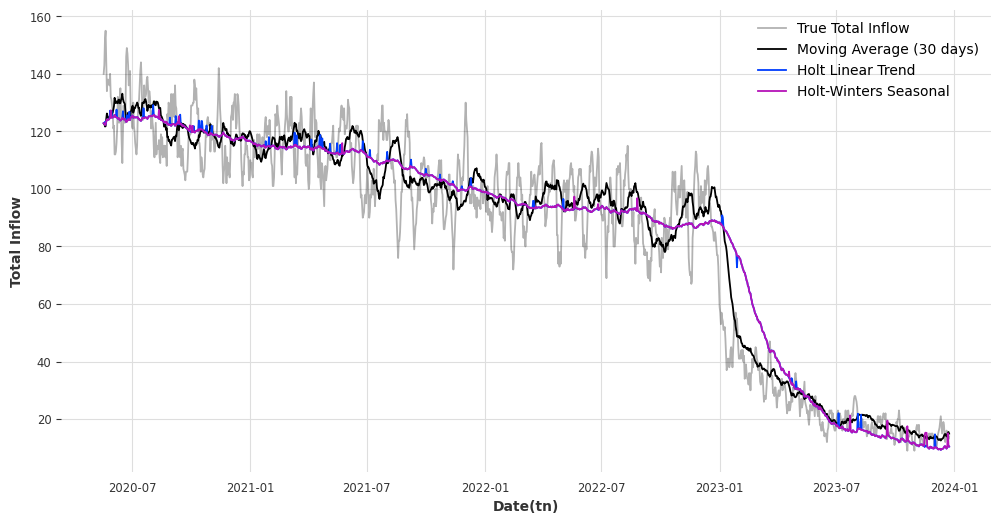

In [55]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(merged_results['Date(tn)'], merged_results['true_total_inflow'], label='True Total Inflow', color='black', alpha=0.3)
plt.plot(merged_results['Date(tn)'], merged_results['MA'], label='Moving Average (30 days)')
plt.plot(merged_results['Date(tn)'], merged_results['HLT'], label='Holt Linear Trend')
plt.plot(merged_results['Date(tn)'], merged_results['HS'], label='Holt-Winters Seasonal')
plt.legend()
plt.xlabel('Date(tn)')
plt.ylabel('Total Inflow')

## residual diagnostics

In [56]:
from darts import TimeSeries
from darts.utils.statistics import plot_residuals_analysis

true_series = TimeSeries.from_dataframe(
    merged_results,
    time_col='Date(tn)',
    value_cols='true_total_inflow',
    freq='D',
    fill_missing_dates=True, # ensure the dates are continuous
    fillna_value= 0 # fill missing values with 0
)
ma_series = TimeSeries.from_dataframe(
    merged_results,
    time_col='Date(tn)',
    value_cols='HLT',
    freq='D',
    fill_missing_dates=True, # ensure the dates are continuous
    fillna_value= 0 # fill missing values with 0
)

Use strided total admissions with non-overlapping forecast window to prevent the systematic auto-correlation.

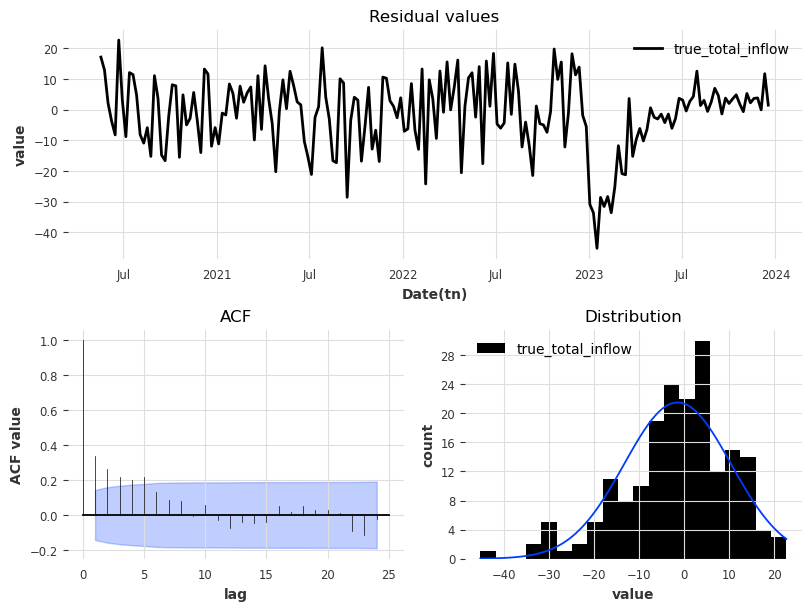

In [58]:
adjusted_ma_series = ma_series[::d]
adjusted_true_series = true_series[::d]

plot_residuals_analysis(adjusted_true_series - adjusted_ma_series)

In [59]:
# Ljung-Box Test
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = adjusted_true_series.values().flatten() - adjusted_ma_series.values().flatten()
lb_test = acorr_ljungbox(residuals, return_df=True)

print(lb_test)

      lb_stat     lb_pvalue
1   21.986550  2.745678e-06
2   35.430827  2.024387e-08
3   44.432486  1.221413e-09
4   52.028060  1.360942e-10
5   61.147606  7.038530e-12
6   64.473577  5.525120e-12
7   65.858207  1.010742e-11
8   67.054269  1.891444e-11
9   67.060822  5.723038e-11
10  67.697447  1.231536e-10


### Evaluation for predictions before 2023

In [63]:
truncated_true_results = true_series.slice(true_series.start_time(),pd.Timestamp('2022-12-31'))
truncated_pred_results = ma_series.slice(ma_series.start_time(),pd.Timestamp('2022-12-31'))

truncated_true_results.start_time(), truncated_true_results.end_time()

(Timestamp('2020-05-18 00:00:00'), Timestamp('2022-12-31 00:00:00'))

In [64]:
truncated_residuals = truncated_true_results[::d].values().flatten() - truncated_pred_results[::d].values().flatten()
lj_box = acorr_ljungbox(truncated_residuals, return_df=True)

print(lj_box)

     lb_stat  lb_pvalue
1   0.050281   0.822574
2   0.632112   0.729019
3   1.430020   0.698513
4   1.493692   0.827758
5   3.136701   0.678920
6   3.152660   0.789457
7   3.181259   0.867743
8   3.191680   0.921759
9   3.858275   0.920490
10  6.057180   0.810437


In [65]:
truncated_results = merged_results[merged_results['Date(tn)'] <= '2022-12-31']

from darts import metrics
true_series_trunc = TimeSeries.from_dataframe(
    truncated_results,
    time_col='Date(tn)',
    value_cols='true_total_inflow',
    freq='D',
    fill_missing_dates=True, # ensure the dates are continuous
    fillna_value= 0 # fill missing values with 0
)
ma_series_trunc = TimeSeries.from_dataframe(
    truncated_results,
    time_col='Date(tn)',
    value_cols='MA',
    freq='D',
    fill_missing_dates=True, # ensure the dates are continuous
    fillna_value= 0 # fill missing values with 0
)
hlt_series_trunc = TimeSeries.from_dataframe(
    truncated_results,
    time_col='Date(tn)',
    value_cols='HLT',
    freq='D',
    fill_missing_dates=True, # ensure the dates are continuous
    fillna_value= 0 # fill missing values with 0
)
hs_series_trunc = TimeSeries.from_dataframe(
    truncated_results,
    time_col='Date(tn)',
    value_cols='HS',
    freq='D',
    fill_missing_dates=True, # ensure the dates are continuous
    fillna_value= 0 # fill missing values with 0
)

test_metrics = {
    'Moving Average': {
        'MAE': metrics.mae(true_series_trunc, ma_series_trunc),
        'RMSE': metrics.rmse(true_series_trunc, ma_series_trunc),
        'MAPE': metrics.mape(true_series_trunc, ma_series_trunc)
    },
    'Holt Linear Trend': {
        'MAE': metrics.mae(true_series_trunc, hlt_series_trunc),
        'RMSE': metrics.rmse(true_series_trunc, hlt_series_trunc),
        'MAPE': metrics.mape(true_series_trunc, hlt_series_trunc)
    },
    'Holt Winter Seasonal': {
        'MAE': metrics.mae(true_series_trunc, hs_series_trunc),
        'RMSE': metrics.rmse(true_series_trunc, hs_series_trunc),
        'MAPE': metrics.mape(true_series_trunc, hs_series_trunc)
    }
}

In [66]:
test_metrics_df = pd.DataFrame.from_dict(test_metrics, orient='index')
test_metrics_df = test_metrics_df.reset_index().rename(columns={'index': 'Model'})
test_metrics_df = test_metrics_df.sort_values(by='MAE')
print(test_metrics_df)

                  Model       MAE       RMSE      MAPE
2  Holt Winter Seasonal  9.022516  10.928764  8.833792
1     Holt Linear Trend  9.045406  10.957361  8.859108
0        Moving Average  9.955148  12.158835  9.801608
